In [124]:
import pandas as pd 
import numpy as np 
import warnings 
warnings.filterwarnings("ignore")

In [125]:
df=pd.read_csv("individual household power consumption.csv", parse_dates=[["Date", "Time"]], dayfirst=True, sep=";")

In [126]:
mv=["nan", "...,", "?"]

In [127]:
df=pd.read_csv("individual household power consumption.csv",sep=";", na_values=mv)

In [128]:
 df["Global_active_power"].fillna(df["Global_active_power"].median(), inplace=True)
 df["Global_reactive_power"].fillna(df["Global_reactive_power"].median(), inplace=True)
 df["Voltage"].fillna(df["Voltage"].median(), inplace=True)
 df["Global_intensity"].fillna(df["Global_intensity"].median(), inplace=True)
 df["Sub_metering_1"].fillna(df["Sub_metering_1"].median(), inplace=True)
 df["Sub_metering_2"].fillna(df["Sub_metering_2"].median(), inplace=True)
 df["Sub_metering_3"].fillna(df["Sub_metering_3"].median(), inplace=True)

In [129]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [130]:
df=df.drop(columns=df.columns[-6:])

In [131]:
df.head()

,Date,Time,Global_active_power
0,16/12/2006,17:24:00,4.216
1,16/12/2006,17:25:00,5.360
2,16/12/2006,17:26:00,5.374
3,16/12/2006,17:27:00,5.388
4,16/12/2006,17:28:00,3.666


In [132]:
df_new=df.drop(columns=["Date"])

In [133]:
df_new.head()

,Time,Global_active_power
0,17:24:00,4.216
1,17:25:00,5.360
2,17:26:00,5.374
3,17:27:00,5.388
4,17:28:00,3.666


<Axes: xlabel='Time', ylabel='Global_active_power'>

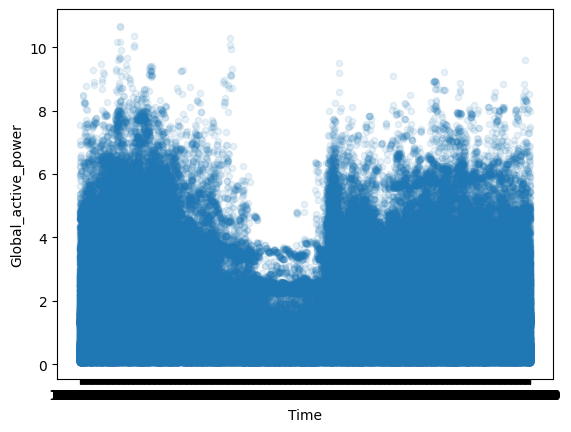

In [134]:
df_new.plot.scatter(x="Time", y="Global_active_power", alpha=0.1)

<Axes: xlabel='Time'>

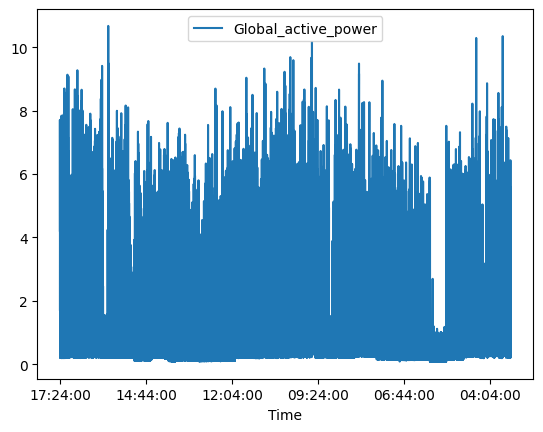

In [135]:
df_new.plot(x="Time", y="Global_active_power")

<Axes: >

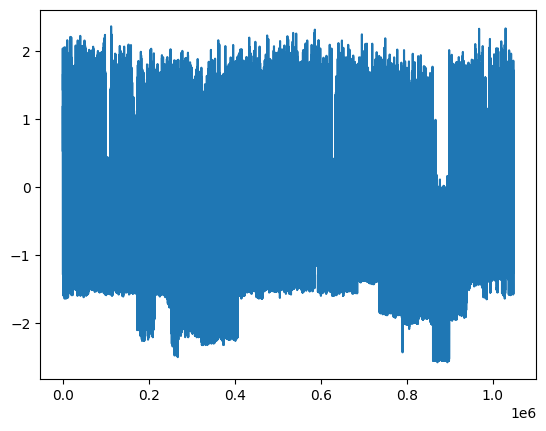

In [136]:
import numpy as np
# One method to get rid of time varying variance is to do a power or log transformation that punishes larger values
# more than smaller values
log_df = df_new.Global_active_power.apply(lambda x: np.log(x))
log_df.plot()

<Axes: >

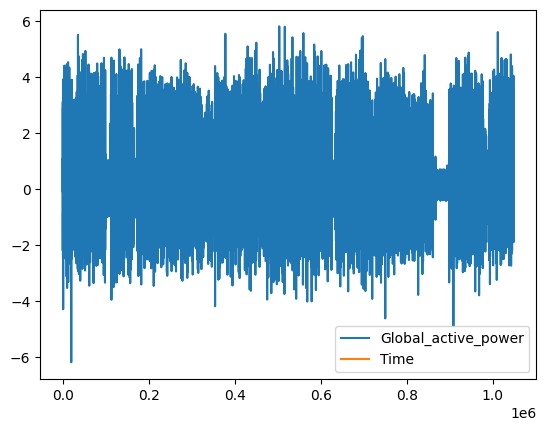

In [139]:
# What if we subtract this rolling mean from the original series?
rolling_mean = df_new.select_dtypes(include="number").rolling(window = 12).mean()

# Subtract rolling_mean from the air_passengers
Power_ac_detrended = df_new - rolling_mean

# Display the plot
Power_ac_detrended.plot()

<Axes: >

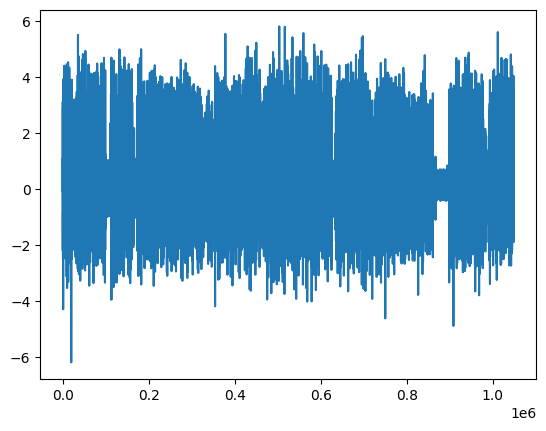

In [142]:
# Exercise: try detrending after taking the log. How does that look?
log_rolling_mean = df_new["Global_active_power"].rolling(window = 12).mean()
log_detrended = df_new["Global_active_power"] - log_rolling_mean
log_detrended.plot()

sea

<Axes: >

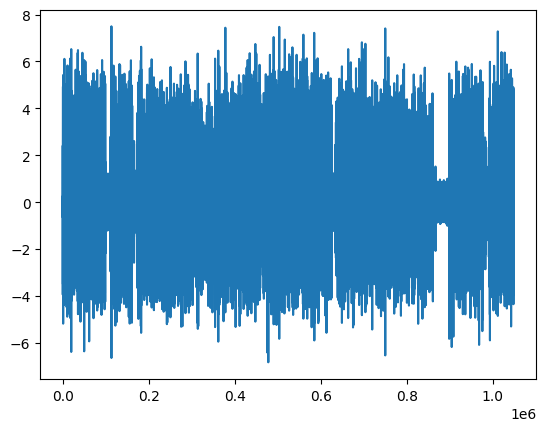

In [143]:
# shift() Shift index by desired number of periods with an optional time `freq`.
# By default It shifts 1 period, check the example details using shift + tab
(df_new.Global_active_power - df_new.Global_active_power.shift(10)).plot()

In [150]:
series = df_new['Global_active_power'].values
print(series)



[4.216 5.36  5.374 ... 0.422 0.422 0.422]


In [151]:
from  statsmodels.tsa.stattools import adfuller
result = adfuller(series, autolag = 'AIC')

MemoryError: Unable to allocate 984. MiB for an array with shape (1048696, 123) and data type float64

In [ ]:
# Augmented Dickey-Fuller test
ADF_result = adfuller(df_new['Global_active_power'])

# Display the results
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

<Axes: >

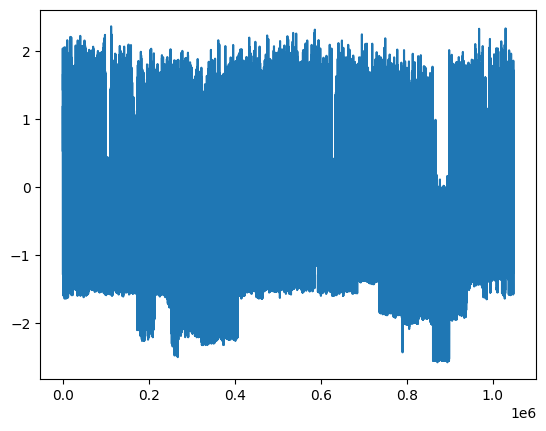

In [121]:
import numpy as np
# One method to get rid of time varying variance is to do a power or log transformation that punishes larger values
# more than smaller values
log_global_ac_po=["Global_active_power"]
log_global_ac_po=np.log(df["Global_active_power"])
log_global_ac_po.plot()

<Axes: >

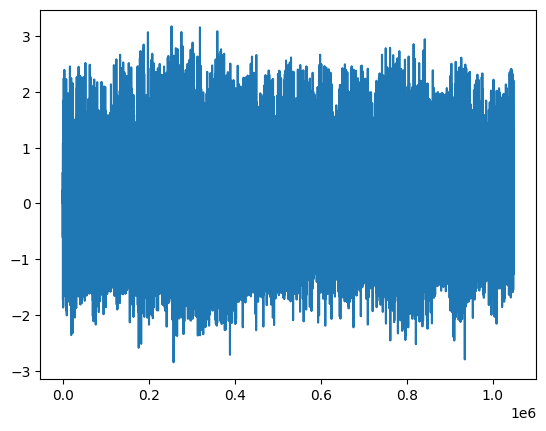

In [78]:
# What if we subtract this rolling mean from the original series?
rolling_mean = global_ac_po.rolling(window = 12).mean()

# Subtract rolling_mean from the air_passengers
po_detrended = global_ac_po - rolling_mean

# Display the plot
po_detrended.plot()

<Axes: >

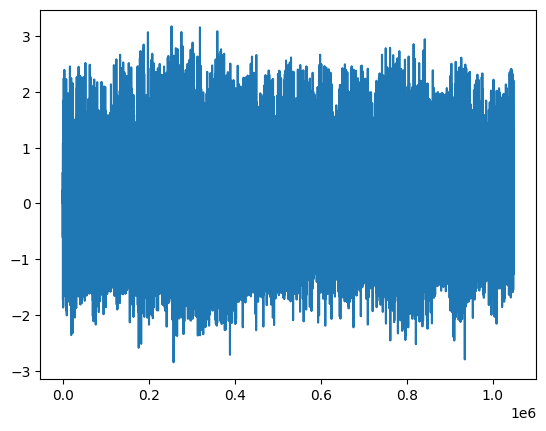

In [82]:
# Exercise: try detrending after taking the log. How does that look?
log_rolling_mean = global_ac_po.rolling(window = 12).mean()
log_detrended = global_ac_po - log_rolling_mean
log_detrended.plot()

sea

<Axes: >

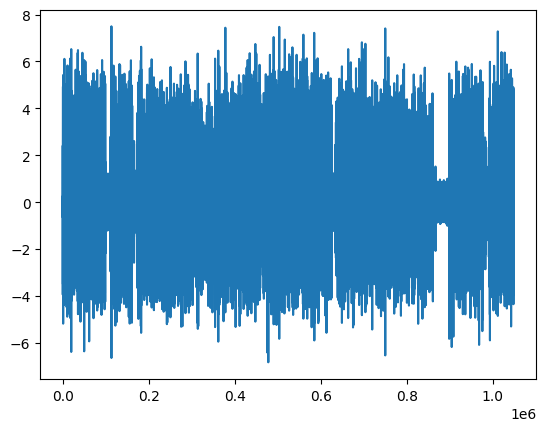

In [86]:
# shift() Shift index by desired number of periods with an optional time `freq`.
# By default It shifts 1 period, check the example details using shift + tab
(df.Global_active_power - df.Global_active_power.shift(10)).plot()

<Axes: >

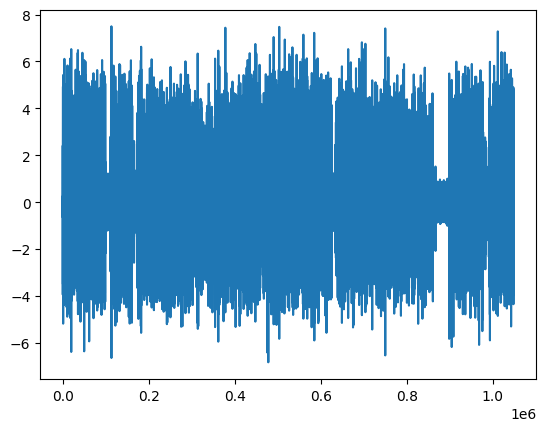

In [88]:
# One common technique is differencing, let's start with log_passengers

log_passengers_diff = df.Global_active_power - df.Global_active_power.shift(10)
log_passengers_diff.plot()

# The function log_passengers.shift() moves the entire time series one step backward (by default, shift(1)).

In [60]:
df.head()

,Date,Time,Global_active_power
0,16/12/2006,17:24:00,4.216
1,16/12/2006,17:25:00,5.360
2,16/12/2006,17:26:00,5.374
3,16/12/2006,17:27:00,5.388
4,16/12/2006,17:28:00,3.666


In [61]:
df["Datetime_Str"]=df["Date"].astype(str)+ " " +df["Time"].astype(str)
df["Datetime"]=pd.to_datetime(df["Datetime_Str"], format ="%d/%m/%Y %H:%M:%S")

In [62]:
df["hour_of_day"]=df["Datetime"].dt.hour

In [63]:
hour_av=df.groupby(["hour_of_day"]).mean(numeric_only=True)
hour_av.head()

,Global_active_power
hour_of_day,
0,0.690978
1,0.550318
2,0.473615
3,0.439418
4,0.436654


<Axes: xlabel='hour_of_day', ylabel='Global_active_power'>

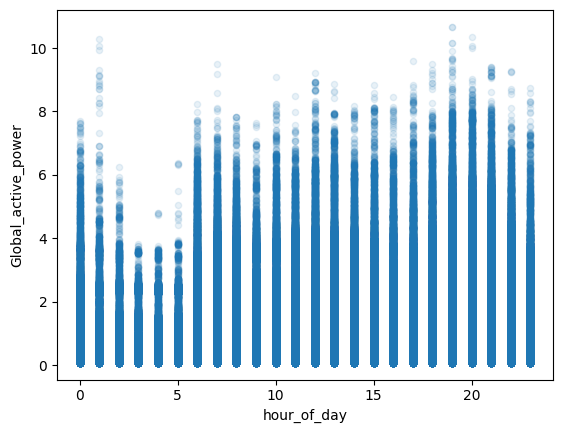

In [64]:
df.plot.scatter(x="hour_of_day", y="Global_active_power", alpha=0.1)

<Axes: xlabel='hour_of_day'>

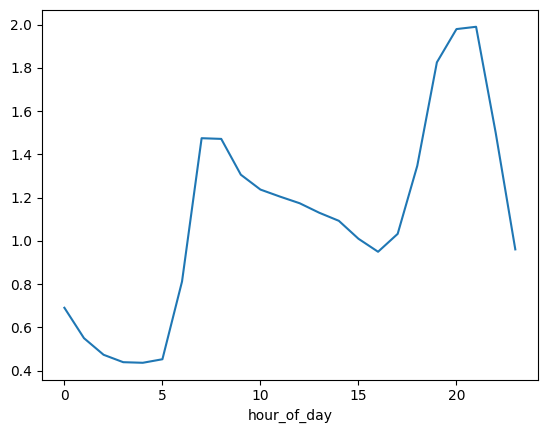

In [65]:
df.groupby("hour_of_day")["Global_active_power"].mean().plot(kind="line")

<Axes: >

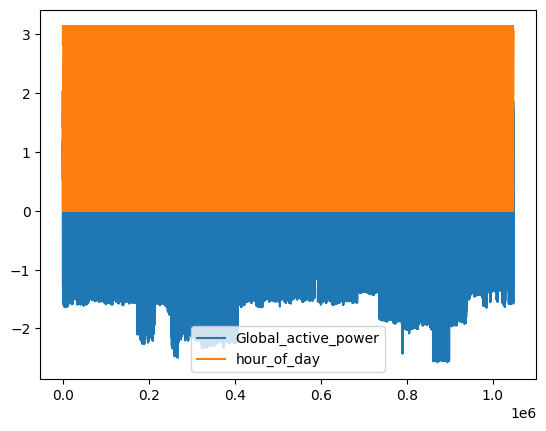

In [66]:
import numpy as np
# One method to get rid of time varying variance is to do a power or log transformation that punishes larger values
# more than smaller values
log_df = df.select_dtypes(include=[np.number]).apply(lambda x: np.log(x))
log_df.plot()